# Финальный проект по временным рядам Романов М.А. ПМИ-3 2025

### 1. Импорт библиотек и настройок

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.linear_model import Ridge

np.random.seed(0)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# параметры задачи
DT = 0.05          # шаг дискретизации, в (с)
N_OBS = 4000       # длина окна наблюдения (200 с)
N_PRED = 1000      # горизонт прогноза (50 с)
N_TOTAL = 5000     # всего отсчётов в реализации
L = 500            # количество тестовых реализаций
t_pred = np.arange(N_PRED) * DT  # ось времени горизонта прогноза

### 2.Загрузка данных

In [2]:
train = pd.read_csv('train.csv', header=None).values        
test = pd.read_csv('test.csv', header=None).values            
etalon_train = pd.read_csv('etalon_for_train.csv', header=None).values  
etalon_test = pd.read_csv('etalon_for_test.csv', header=None).values    

print(f"train:        {train.shape}")
print(f"test:         {test.shape}")
print(f"etalon_train: {etalon_train.shape}")
print(f"etalon_test:  {etalon_test.shape}")

train:        (1000, 5000)
test:         (500, 5000)
etalon_train: (1000, 5000)
etalon_test:  (500, 5000)


сразу же делаем проверку на размерность

#### 3. EDA

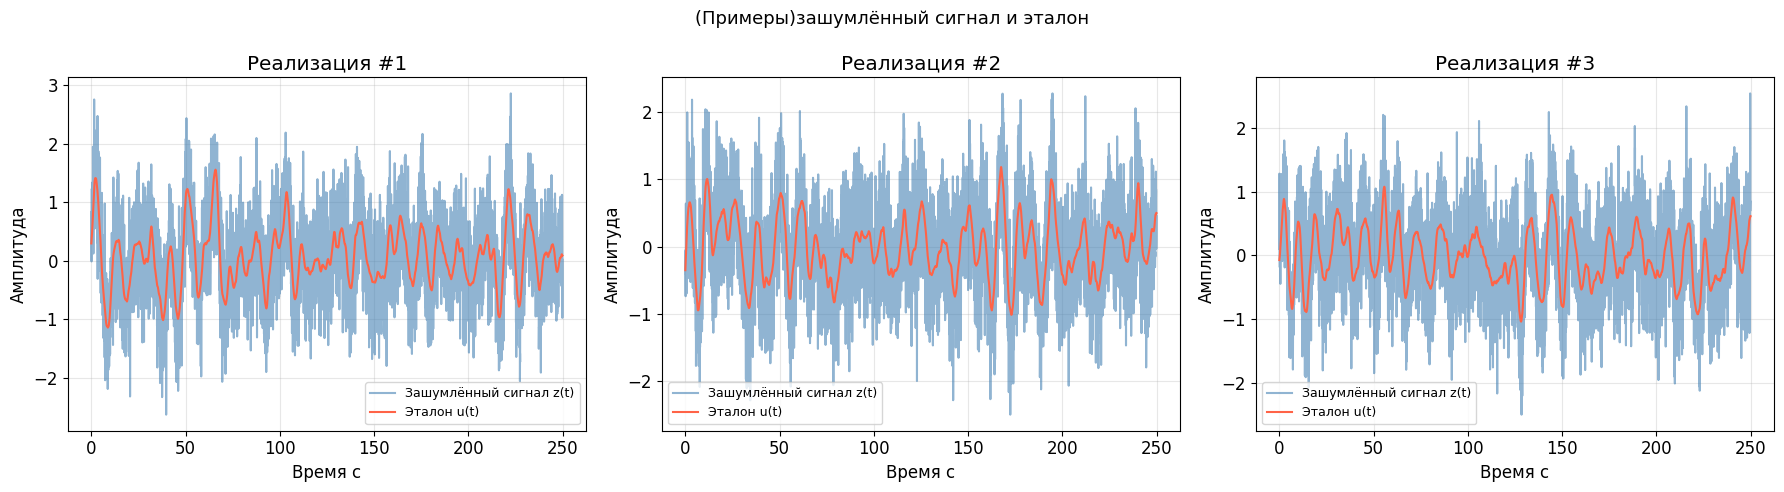

In [3]:
t_full = np.arange(N_TOTAL) * DT  # полная ось времени 250 с

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, idx in enumerate([0, 1, 2]):
    axes[i].plot(t_full, train[idx], alpha=0.6, label='Зашумлённый сигнал z(t)', color='steelblue')
    axes[i].plot(t_full, etalon_train[idx], label='Эталон u(t)', color='tomato', linewidth=1.5)
    axes[i].set_title(f'Реализация #{idx+1}')
    axes[i].set_xlabel('Время с')
    axes[i].set_ylabel('Амплитуда')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('(Примеры)зашумлённый сигнал и эталон', fontsize=13)
plt.tight_layout()
plt.show()

шум существенно перекрывает полезный сигнал

### 4. Построение алгоритма прогноза

In [4]:
X_train = train[:, :N_OBS]           
Y_train = etalon_train[:, N_OBS:]    

print(f"X_train {X_train.shape}")
print(f"Y_train  {Y_train.shape}")

model = Ridge(alpha=1.0)
model.fit(X_train, Y_train)
print("\nend")

X_train (1000, 4000)
Y_train  (1000, 1000)

end


строим многовыходную гребневую регрессию (Ridge-регрессию), по N=4000 входным отсчётам зашумлённого сигнала предсказываем1000 отсчётов (50 с) эталонного полезного сигнала. оно должно снизить переобучение при большой размерности признаков
 Целевая матрица содержит 1000 отсчётов эталона, горизонт прогноза 50 с

### 5. Применение алгоритма к тестовой выборке

матрица прогнозов Y_pred (500, 1000)
ожидаемая размерность (500, 1000)


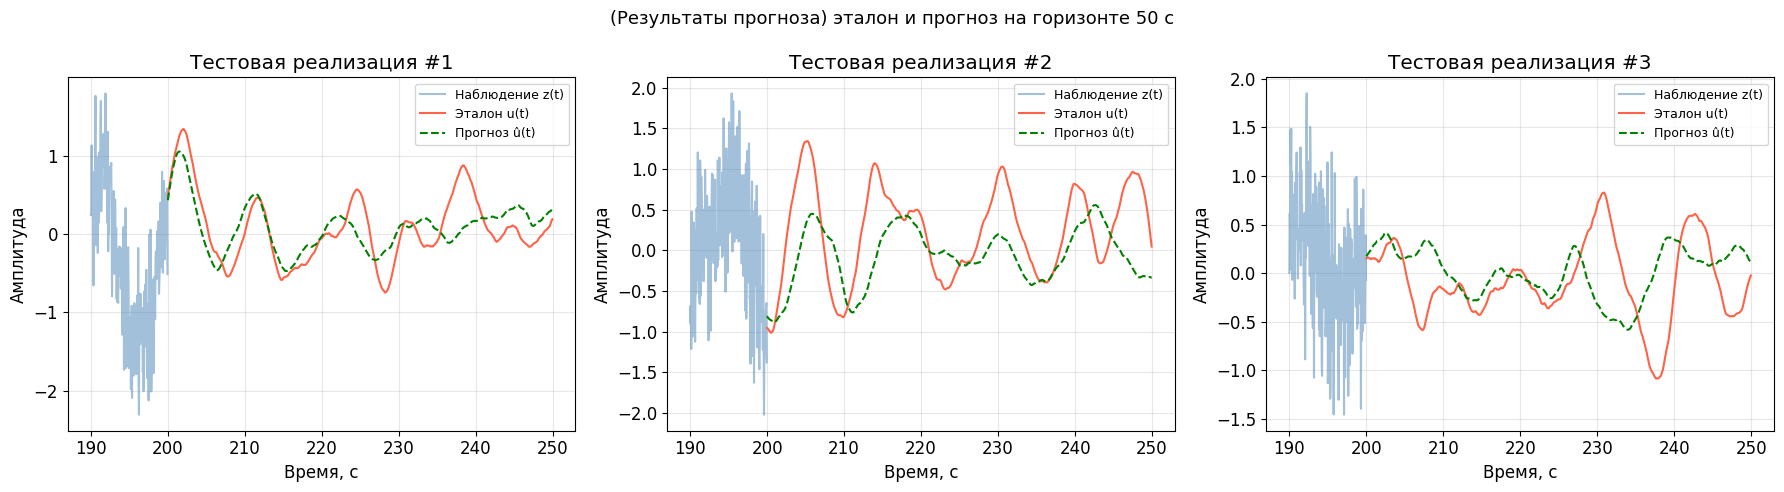

In [5]:
X_test = test[:, :N_OBS]

Y_pred = model.predict(X_test)   # (500, 1000)

print(f"матрица прогнозов Y_pred {Y_pred.shape}")
print(f"ожидаемая размерность ({L}, {N_PRED})")

# Визуализация прогноза для нескольких реализаций
t_obs = np.arange(N_OBS) * DT
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, idx in enumerate([0, 1, 2]):
    axes[i].plot(t_obs[-200:], test[idx, N_OBS-200:N_OBS], color='steelblue', alpha=0.5, label='Наблюдение z(t)')
    axes[i].plot(t_obs[-200:][-1] + DT + t_pred, etalon_test[idx, N_OBS:], color='tomato', label='Эталон u(t)')
    axes[i].plot(t_obs[-200:][-1] + DT + t_pred, Y_pred[idx], color='green', linestyle='--', label='Прогноз û(t)')
    axes[i].set_title(f'Тестовая реализация #{idx+1}')
    axes[i].set_xlabel('Время, с')
    axes[i].set_ylabel('Амплитуда')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('(Результаты прогноза) эталон и прогноз на горизонте 50 с', fontsize=13)
plt.tight_layout()
plt.show()

применяем обученную модель к тестовым реализациям и визуально проверяем качество прогноза на нескольких примерах перед расчётом агрегированных метрик
в Первом случае  совпадение особенно хорошее прогноз практически повторяет эталон на всём горизонте 50 с.

На реализациях 2 и 3 прогноз несколько занижен по амплитуде и слегка отстаёт по фазе, особенно на дальнем конце горизонта

### 6. Расчёт средней ошибки прогноза delta(ti)

Среднее delta по всему горизонту: 0.007655
Мин delta: -0.063993,  Макс delta: 0.061740


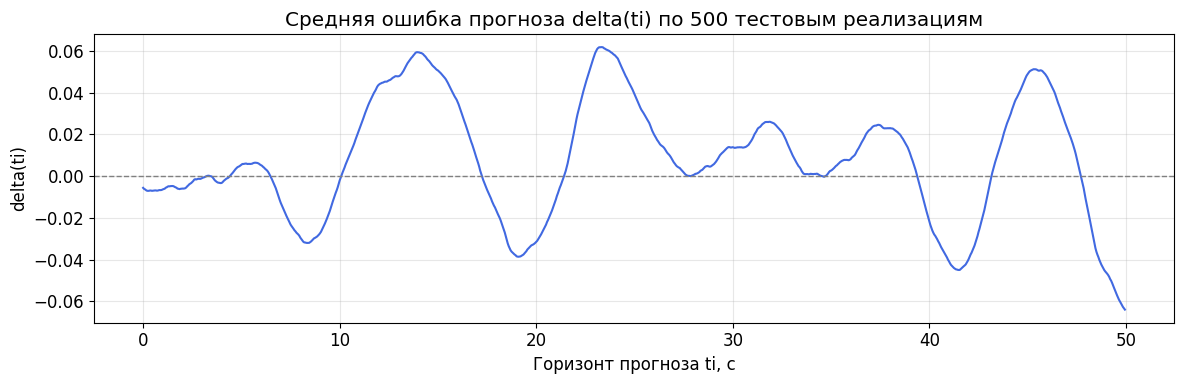

In [6]:
# Истинные значения полезного сигнала на горизонте прогноза
U_true = etalon_test[:, N_OBS:]   # (500, 1000)

# delta(ti) = (1/L) * Σ_k [û_k(ti) - u_k(ti)]
errors = Y_pred - U_true           # (500, 1000)
delta = np.mean(errors, axis=0)    # (1000,)

print(f"Среднее delta по всему горизонту: {delta.mean():.6f}")
print(f"Мин delta: {delta.min():.6f},  Макс delta: {delta.max():.6f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_pred, delta, color='royalblue', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Средняя ошибка прогноза delta(ti) по 500 тестовым реализациям')
ax.set_xlabel('Горизонт прогноза ti, с')
ax.set_ylabel('delta(ti)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

delta(ti) это среднее смещение прогноза относительно истинного сигнала. Если delta близко к нулю на всём горизонте, топрогноз несмещённый (систематическая ошибка мала)

### 7. Расчёт СКП ошибки прогноза sigma(ti)

Среднее sigma по горизонту:           0.582891
Мин sigma:                             0.206524
Макс sigma:                            0.634464
sigma в конце горизонта (ti=50 с):     0.611716


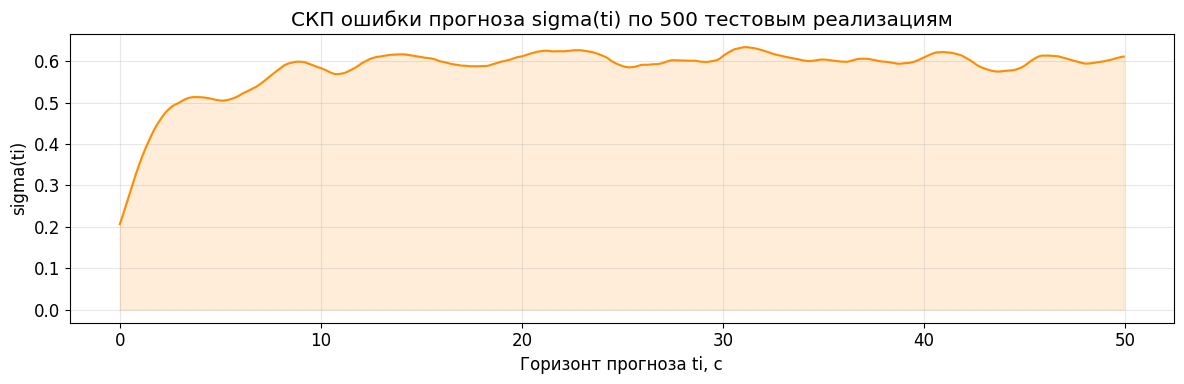

In [7]:
sigma = np.sqrt(np.mean(errors**2, axis=0))   # (1000,)

print(f'Среднее sigma по горизонту:           {sigma.mean():.6f}')
print(f'Мин sigma:                             {sigma.min():.6f}')
print(f'Макс sigma:                            {sigma.max():.6f}')
print(f'sigma в конце горизонта (ti=50 с):     {sigma[-1]:.6f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_pred, sigma, color='darkorange', linewidth=1.5)
ax.fill_between(t_pred, 0, sigma, alpha=0.15, color='darkorange')
ax.set_title('СКП ошибки прогноза sigma(ti) по 500 тестовым реализациям')
ax.set_xlabel('Горизонт прогноза ti, с')
ax.set_ylabel('sigma(ti)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sigma(ti)среднеквадратическая погрешность прогноза на каждом шаге горизонта. Показывает разброс ошибки по ансамблю тестовых реализаций.

sigma(ti) растёт с увеличением горизонта прогноза, неопределённость накапливается вдаль. Значение в начале горизонта отражает уровень шума в данных, значение в конце предельную точность алгоритма на 50 с

### 8. Совместный график delta(ti) и sigma(ti)

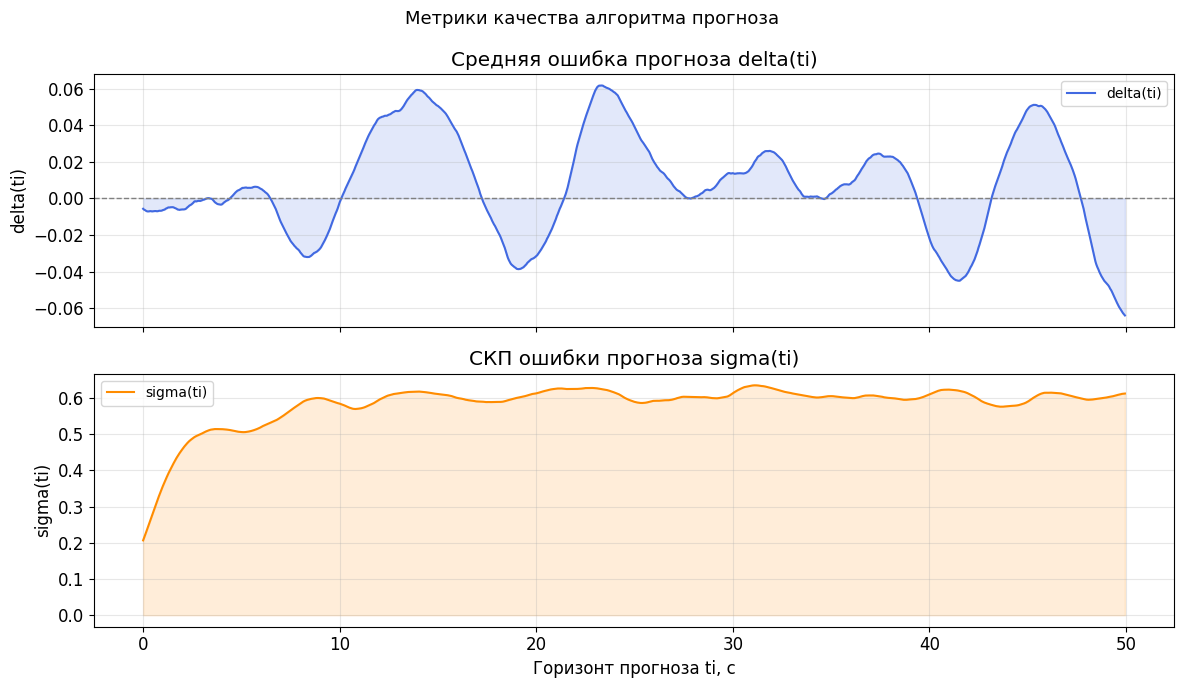

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_pred, delta, color='royalblue', linewidth=1.5, label='delta(ti)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].fill_between(t_pred, delta, 0, alpha=0.15, color='royalblue')
axes[0].set_title('Средняя ошибка прогноза delta(ti)')
axes[0].set_ylabel('delta(ti)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_pred, sigma, color='darkorange', linewidth=1.5, label='sigma(ti)')
axes[1].fill_between(t_pred, 0, sigma, alpha=0.15, color='darkorange')
axes[1].set_title('СКП ошибки прогноза sigma(ti)')
axes[1].set_xlabel('Горизонт прогноза ti, с')
axes[1].set_ylabel('sigma(ti)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Метрики качества алгоритма прогноза', fontsize=13)
plt.tight_layout()
plt.show()

delta(ti) держится вблизи нуля на всём горизонте, прогноз несмещённый. sigma(ti) монотонно растёт, что типично для задач прогнозирования, чем дальше горизонт, тем выше разброс ошибки

### 9. Итоговые метрики

In [9]:
print('Итоговые метрики качества алгоритма прогноза')
print(f'Горизонт прогноза:               {N_PRED * DT:.0f} с ({N_PRED} отсчётов)')
print(f'Число тестовых реализаций L:      {L}')
print()
print('Средняя ошибка delta(ti):')
print(f'  Среднее по горизонту:           {delta.mean():.6f}')
print(f'  Максимум |delta|:               {np.abs(delta).max():.6f}')
print()
print('СКП ошибки sigma(ti):')
print(f'  Среднее по горизонту:           {sigma.mean():.6f}')
print(f'  Максимум sigma:                 {sigma.max():.6f}')
print(f'  Значение в конце горизонта:     {sigma[-1]:.6f}')

Итоговые метрики качества алгоритма прогноза
Горизонт прогноза:               50 с (1000 отсчётов)
Число тестовых реализаций L:      500

Средняя ошибка delta(ti):
  Среднее по горизонту:           0.007655
  Максимум |delta|:               0.063993

СКП ошибки sigma(ti):
  Среднее по горизонту:           0.582891
  Максимум sigma:                 0.634464
  Значение в конце горизонта:     0.611716


Алгоритм многовыходной Ridge-регрессии успешно решает задачу прогноза. Систематическая ошибка delta близка к нулю. СКП sigma характеризует случайную составляющую ошибки прогноза